# Руководство по симулятору Otter and Oil

Этот ноутбук повторяет ключевую функциональность `main.py`, но выполняет все действия последовательно и
не требует внешнего конфигурационного файла. Параметры моделирования настраиваются прямо в ячейках,
а данные о пространстве считываются из готовых JSON-файлов.


## Настройка параметров

Измените словари в разделе "Параметры моделирования", чтобы выбрать нужное пространство, контроллеры,
количество циклов и другие опции. После правок последовательно выполните все ячейки ноутбука.


In [1]:
from pathlib import Path
from typing import Any, Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

import spaces as sp
import vehicles as vs
from controllers.manager import ControllerManager
from controllers.plotter import ControllerPlotter, PlotRenderOptions, TrackRenderOptions
from tools.dataStorage import Arguments, ControllerVehiclePairs, DataStorage, clean_data
from tools.random_generators import color_generator, number_generator
from tools.common import plotting_all

plt.rcParams["animation.html"] = "jshtml"


def controller_label(idx, controller) -> str:
    name = getattr(controller, 'name', '')
    abbreviation = getattr(controller, 'abbreviation', '')
    base = name or abbreviation
    if base:
        return f"{base}#{idx + 1}"
    return f"controller #{idx + 1}"


def prepare_animation_datasets(sim_data: Iterable[np.ndarray], metadata: dict) -> Sequence[dict]:
    datasets = []
    colors = list(metadata.get('colors', []))
    local_color_generator = color_generator()
    grid_size = int(metadata.get('grid_size', 1)) or 1

    for idx, vehicle_data in enumerate(sim_data):
        array = np.asarray(vehicle_data)
        if array.ndim != 2 or array.shape[1] < 3:
            logger.warning('Пропущены данные агента %d: ожидается матрица с >= 3 колонками', idx + 1)
            continue

        step = max(array.shape[0] // grid_size, 1)
        x = array[:, 0][::step]
        y = array[:, 1][::step]
        z = array[:, 2][::step]
        dataset = np.array([y, x, -z])

        color = colors[idx] if idx < len(colors) else next(local_color_generator)
        datasets.append({
            'data': dataset,
            'color': color,
            'label': f"агент {idx + 1}",
        })

    return datasets


def create_track_animation(controller, metadata: dict, datasets: Sequence[dict], fps: int):
    if not datasets:
        return None

    grid_x = np.asarray(metadata['grid_x'])
    grid_y = np.asarray(metadata['grid_y'])
    grid_z = np.asarray(metadata['grid_z'])
    isolines = metadata.get('isolines', 10)
    target_isoline = metadata.get('target_isoline')

    if np.isscalar(isolines):
        levels = np.linspace(grid_z.min(), grid_z.max(), int(isolines))
    else:
        isolines_array = np.asarray(isolines)
        if isolines_array.ndim == 0:
            levels = isolines_array.reshape(1)
        else:
            levels = isolines_array

    fig, ax = plt.subplots(figsize=(8, 8))
    contour = ax.contour(grid_x, grid_y, grid_z, levels=levels, cmap='viridis')
    ax.clabel(contour, inline=True, fontsize=8)

    if target_isoline is not None:
        ax.contour(grid_x, grid_y, grid_z, levels=[target_isoline], colors='red', linewidths=2)

    ax.set_xlabel('X, m / East')
    ax.set_ylabel('Y, m / North')
    ax.set_title(getattr(controller, 'name', 'Контроллер'))
    ax.set_aspect('equal', adjustable='box')

    line_entries = []
    quivers = []
    max_frames = 0
    for entry in datasets:
        data = entry['data']
        color = entry['color']
        label = entry['label']

        line, = ax.plot([], [], lw=2, c=color, label=label)
        quiver = ax.quiver([], [], [], [], angles='xy', scale_units='xy', scale=1, color=color, width=0.02)
        line_entries.append((line, data))
        quivers.append(quiver)
        max_frames = max(max_frames, data.shape[1])

    ax.legend()

    fps = int(fps) if fps else 0
    interval = 1000.0 / fps if fps > 0 else 200.0

    def update(frame_index: int):
        artists = []
        for (line, data), quiver in zip(line_entries, quivers):
            limit = min(frame_index + 1, data.shape[1])
            line.set_data(data[0, :limit], data[1, :limit])

            current_idx = limit - 1
            prev_idx = max(current_idx - 1, 0)
            dx = data[0, current_idx] - data[0, prev_idx]
            dy = data[1, current_idx] - data[1, prev_idx]
            norm = np.hypot(dx, dy)
            if norm < 1e-6:
                dx, dy = 1.0, 0.0
            else:
                scale = 2.0 / norm
                dx *= scale
                dy *= scale

            quiver.set_offsets([data[0, current_idx], data[1, current_idx]])
            quiver.set_UVC(dx, dy)
            artists.extend([line, quiver])

        return artists

    animation = FuncAnimation(fig, update, frames=max_frames, interval=interval, blit=False, repeat=True)
    html = HTML(animation.to_jshtml())
    plt.close(fig)
    return html


project_root = Path.cwd()
print("Рабочая директория: %s", project_root)


Рабочая директория: %s /home/artem/dev/diser/OtterAndOil


In [2]:
# Параметры моделирования
simulation_parameters = {
    'clean_cache': False,
    'big_picture': False,
    'not_animated': True,
    'store_raw': False,
    'separating_plots': False,
    'store_plot': False,
    'isometric': False,
    'dynamic_error_max': False,
    'for_publication': False,
    'plot_config': 'plot_config.json',
    'use_latex': True,
    'error_max_cap': 20,
    'eps': 0.001,
    'smoothing': 99,
    'grid_size': 500,
    'axis_abs_max': 26,
    'isolines': 10,
    'peaks_filename': 'peaks_.json',
    'cache_dir': 'data_tutorial',
    'peak_type': 'gaussian',
    'shift_vehicle': [-10, 0],
    'shift_xyz': [0, 0, 0],
    'target_isoline': 10,
    'sim_time_sec': 30,
    'sample_time': 0.02,
    'cycles': 1,
    'radius': 1,
    'FPS': 30,
    'V_current': 0,
    'beta_current': 30.0,
    'log_level': 'INFO',
    'controller_vehicle_pairs': [
        {
            'vehicle_type': 'otter',
            'controller_type': 'intensity',
            'vehicles': 2,
            'start_points': [[-10, 0], [-8, 0]],
        },
        {
            'vehicle_type': 'otter',
            'controller_type': 'intensity_and_linear_velocity_nonlinear_pid_control',
            'vehicles': 1,
            'start_points': [[-6, 0]],
        },
    ],
}
simulation_parameters


{'clean_cache': False,
 'big_picture': False,
 'not_animated': True,
 'store_raw': False,
 'separating_plots': False,
 'store_plot': False,
 'isometric': False,
 'dynamic_error_max': False,
 'for_publication': False,
 'plot_config': 'plot_config.json',
 'use_latex': True,
 'error_max_cap': 20,
 'eps': 0.001,
 'smoothing': 99,
 'grid_size': 500,
 'axis_abs_max': 26,
 'isolines': 10,
 'peaks_filename': 'peaks_.json',
 'cache_dir': 'data_tutorial',
 'peak_type': 'gaussian',
 'shift_vehicle': [-10, 0],
 'shift_xyz': [0, 0, 0],
 'target_isoline': 10,
 'sim_time_sec': 30,
 'sample_time': 0.02,
 'cycles': 1,
 'radius': 1,
 'FPS': 30,
 'V_current': 0,
 'beta_current': 30.0,
 'log_level': 'INFO',
 'controller_vehicle_pairs': [{'vehicle_type': 'otter',
   'controller_type': 'intensity',
   'vehicles': 2,
   'start_points': [[-10, 0], [-8, 0]]},
  {'vehicle_type': 'otter',
   'controller_type': 'intensity_and_linear_velocity_nonlinear_pid_control',
   'vehicles': 1,
   'start_points': [[-6, 0]]}]

In [3]:
arguments = Arguments(**simulation_parameters)

controller_pairs = ControllerVehiclePairs(arguments.controller_vehicle_pairs)

if arguments.clean_cache:
    clean_data(arguments.cache_dir)

global_color_generator = color_generator()
serial_numbers = number_generator()
controller_vehicle_groups = []

for assignment in controller_pairs:
    vehicles = []
    for vehicle_cfg in assignment.vehicles:
        starting_point = tuple(vehicle_cfg.start_point)
        vehicle = vs.create_instance(
            vehicle_cfg.vehicle_type,
            V_current=arguments.V_current,
            serial_number=next(serial_numbers),
            shift=getattr(arguments, 'shift_vehicle', None),
            color=next(global_color_generator),
            starting_point=starting_point,
        )
        vehicles.append(vehicle)
        print(vehicle)
    controller_vehicle_groups.append((assignment, vehicles))

controller_manager = ControllerManager(controller_vehicle_groups, arguments)

space = sp.create_instance(
    arguments.peak_type,
    x_range=(-arguments.axis_abs_max, arguments.axis_abs_max),
    y_range=(-arguments.axis_abs_max, arguments.axis_abs_max),
    grid_size=arguments.grid_size,
    shift_xyz=arguments.shift_xyz,
    space_filename=arguments.peaks_filename,
    target_isoline=arguments.target_isoline,
)
space.set_contour_points(tol=1)
print(space)


---vehicle--------------------------------------------------------------------------
Otter USV (see 'otter.py' for more details)
Length: 2.0 m
Control: sigma
Starting point: [-20.0, 0.0]
---vehicle--------------------------------------------------------------------------
Otter USV (see 'otter.py' for more details)
Length: 2.0 m
Control: sigma
Starting point: [-18.0, 0.0]
---vehicle--------------------------------------------------------------------------
Otter USV (see 'otter.py' for more details)
Length: 2.0 m
Control: sigma
Starting point: [-16.0, 0.0]
---space--------------------------------------------------------------------
Space type: gaussian
Shifting space: 
	shift_x=0
	shift_y=0
	shift_z=0
Target isoline: 10


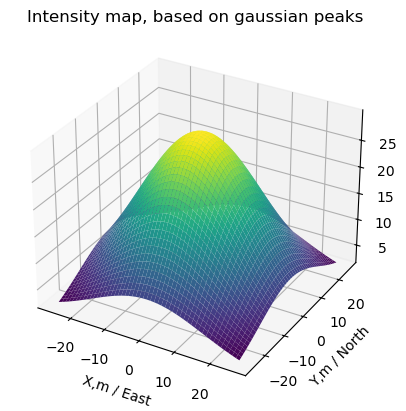

Запуск моделирования для intensity#1


Vehicle Simulation x1: 100%|████████████████████████████████████████████████████████████████████████████| 1501/1501 [00:00<00:00, 4788.44it/s]


Моделирование завершено для intensity#1
Запуск моделирования для intensity#2


Vehicle Simulation x1: 100%|████████████████████████████████████████████████████████████████████████████| 1501/1501 [00:00<00:00, 4918.78it/s]


Моделирование завершено для intensity#2
Запуск моделирования для intensity_and_linear_velocity_nonlinear_pid_control#3


Vehicle Simulation x1: 100%|████████████████████████████████████████████████████████████████████████████| 1501/1501 [00:00<00:00, 5806.74it/s]

Моделирование завершено для intensity_and_linear_velocity_nonlinear_pid_control#3


In [4]:
data_storage = DataStorage(space.type, 1, arguments.cache_dir)
space.set_data_storage(data_storage)
plotting_all(space, store_plot=arguments.store_plot)

controller_runs = controller_manager.initialize_controllers(space=space, data_storage=data_storage)
controllers_only = [controller for controller, _ in controller_runs]
controller_labels = {idx: controller_label(idx, controller) for idx, controller in enumerate(controllers_only)}

for idx, controller in enumerate(controllers_only):
    label = controller_labels[idx]
    print(f"Запуск моделирования для {label}")
    controller.simultaneous_simulate()
    controller_manager.set_run_result(idx)
    print(f"Моделирование завершено для {label}")

controller_runs = list(controller_manager.controller_runs)
controllers_only = [controller for controller, _ in controller_runs]
controller_labels = {idx: controller_label(idx, controller) for idx, controller in enumerate(controllers_only)}

plotter = ControllerPlotter(
    controllers_only,
    plot_config_path=arguments.plot_config,
    use_latex=getattr(arguments, 'use_latex', True),
    plot_options=PlotRenderOptions(
         big_picture=arguments.big_picture,
         separate_plots=getattr(arguments, 'separating_plots', False),
         store_plots=arguments.store_plot,
         for_publication=arguments.for_publication,
    ),
    track_options=TrackRenderOptions(
         big_picture=arguments.big_picture,
         not_animated=arguments.not_animated,
         store_plot=arguments.store_plot,
    ),
    data_storage=data_storage
)

for controller, _ in controller_runs:
    controller.errors_avg = np.cumsum(controller.errors_norm, axis=1) / (
        np.arange(controller.errors_norm.shape[1]) + 1
    )

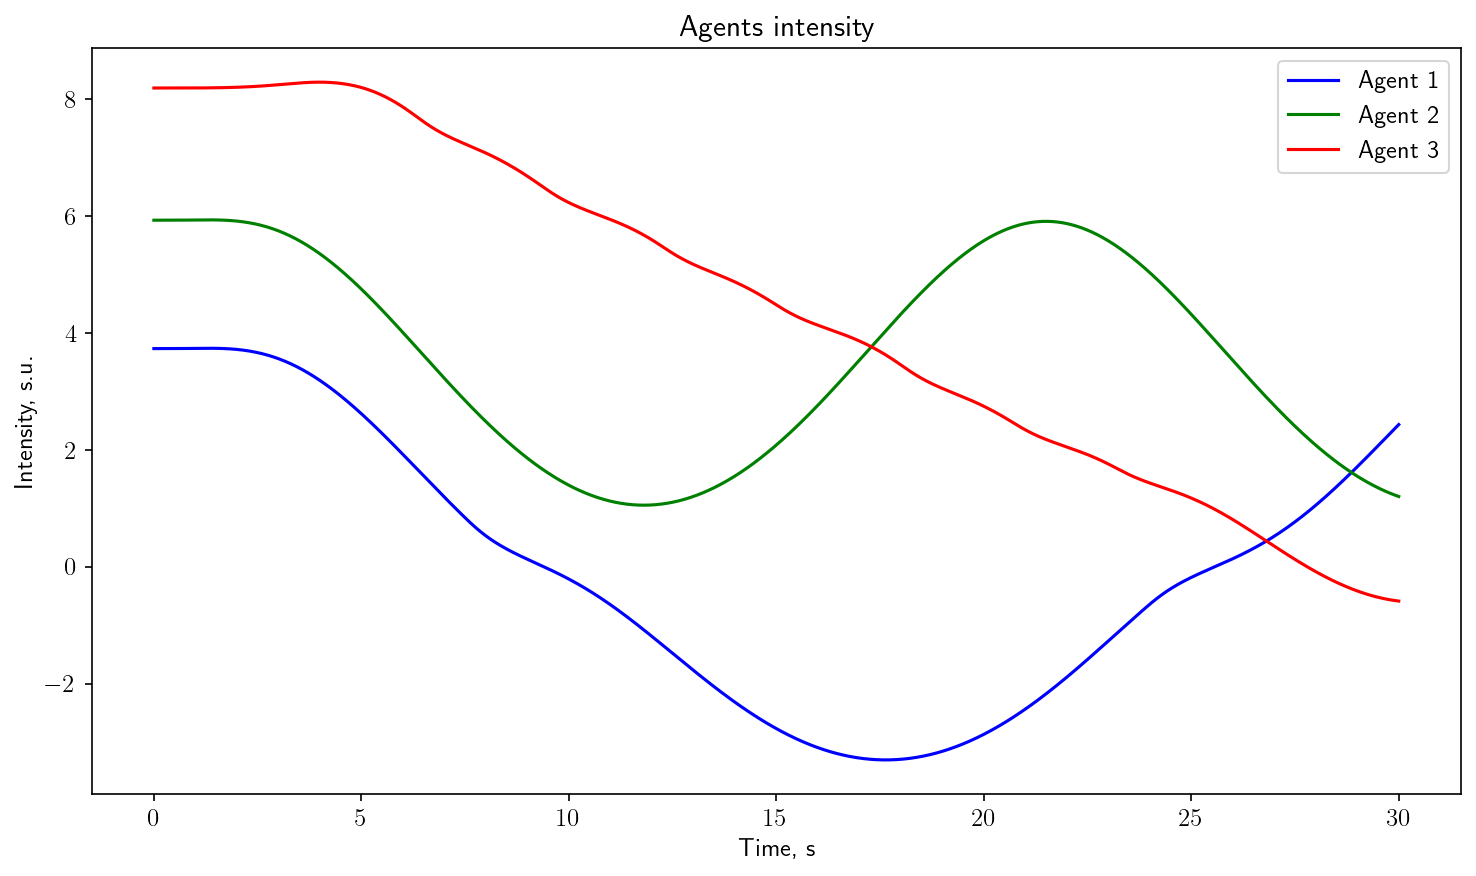

In [5]:
plotter.plotting_intensity(combine=True)

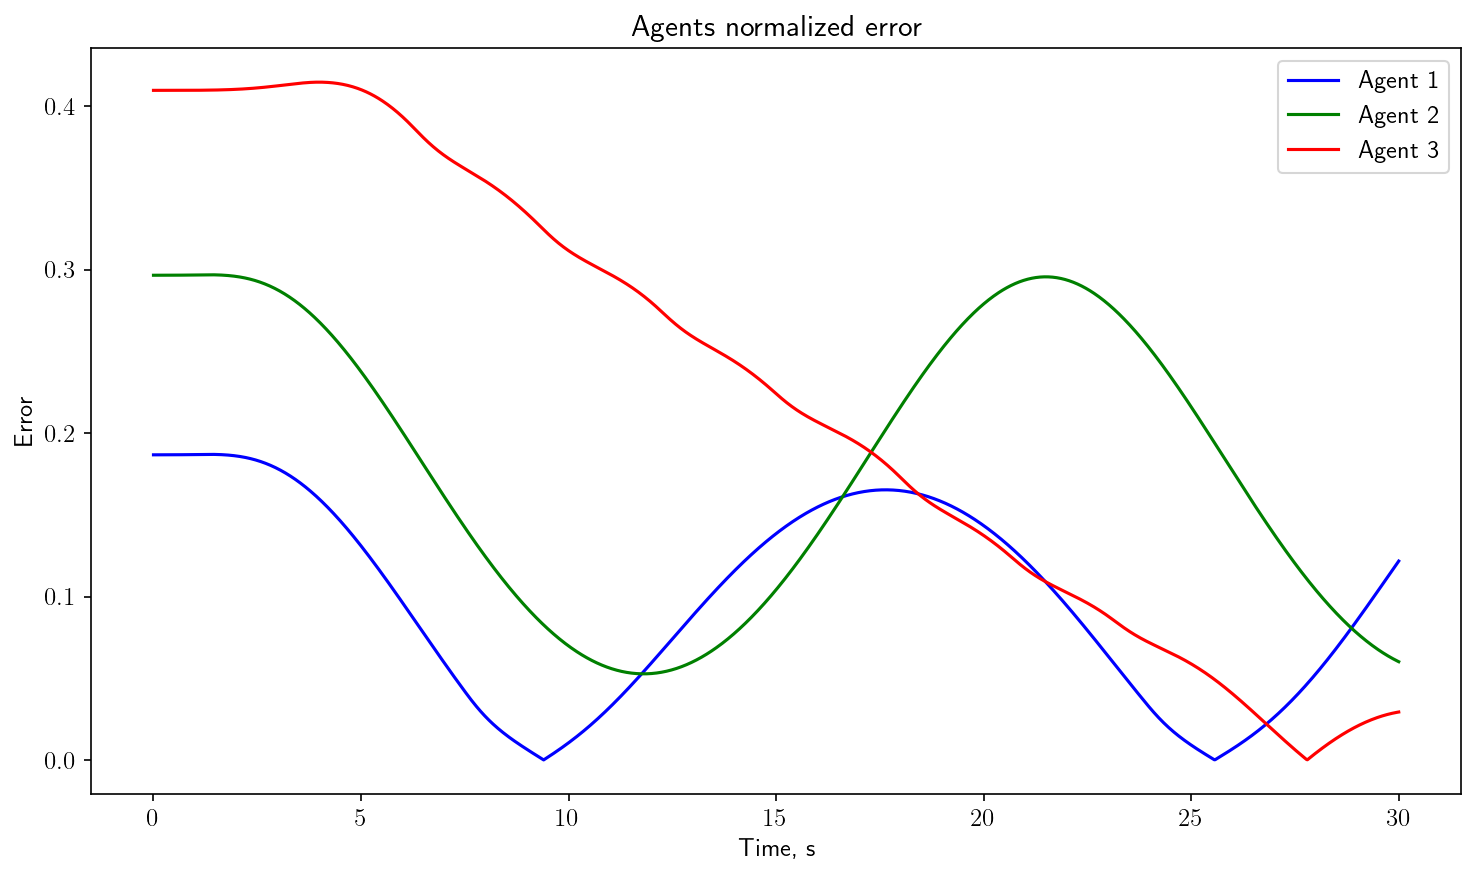

In [6]:
plotter.plotting_error(combine=True)

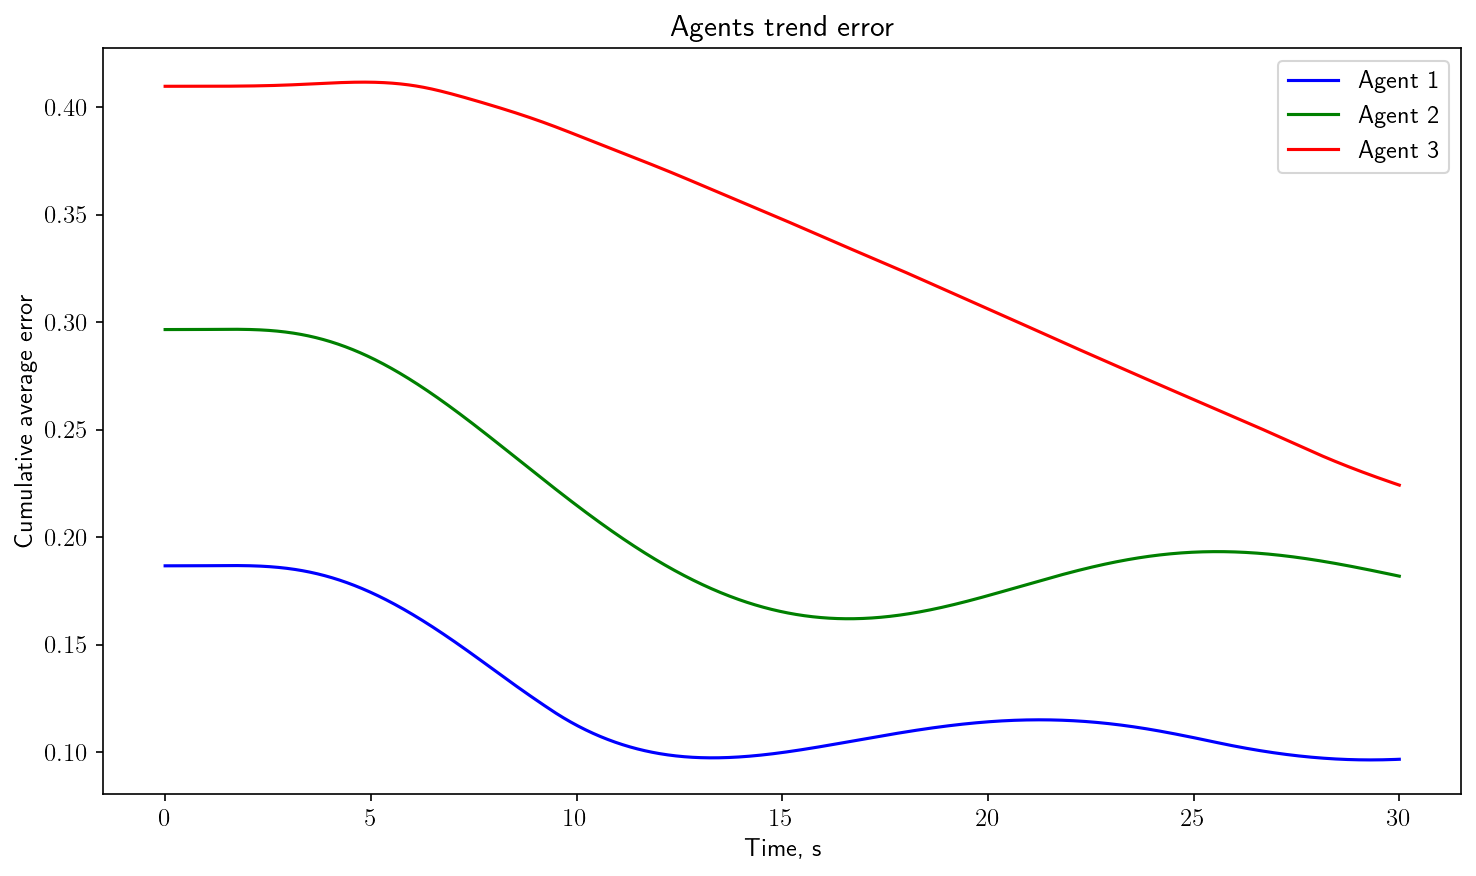

In [7]:
plotter.plotting_error_avg(combine=True)

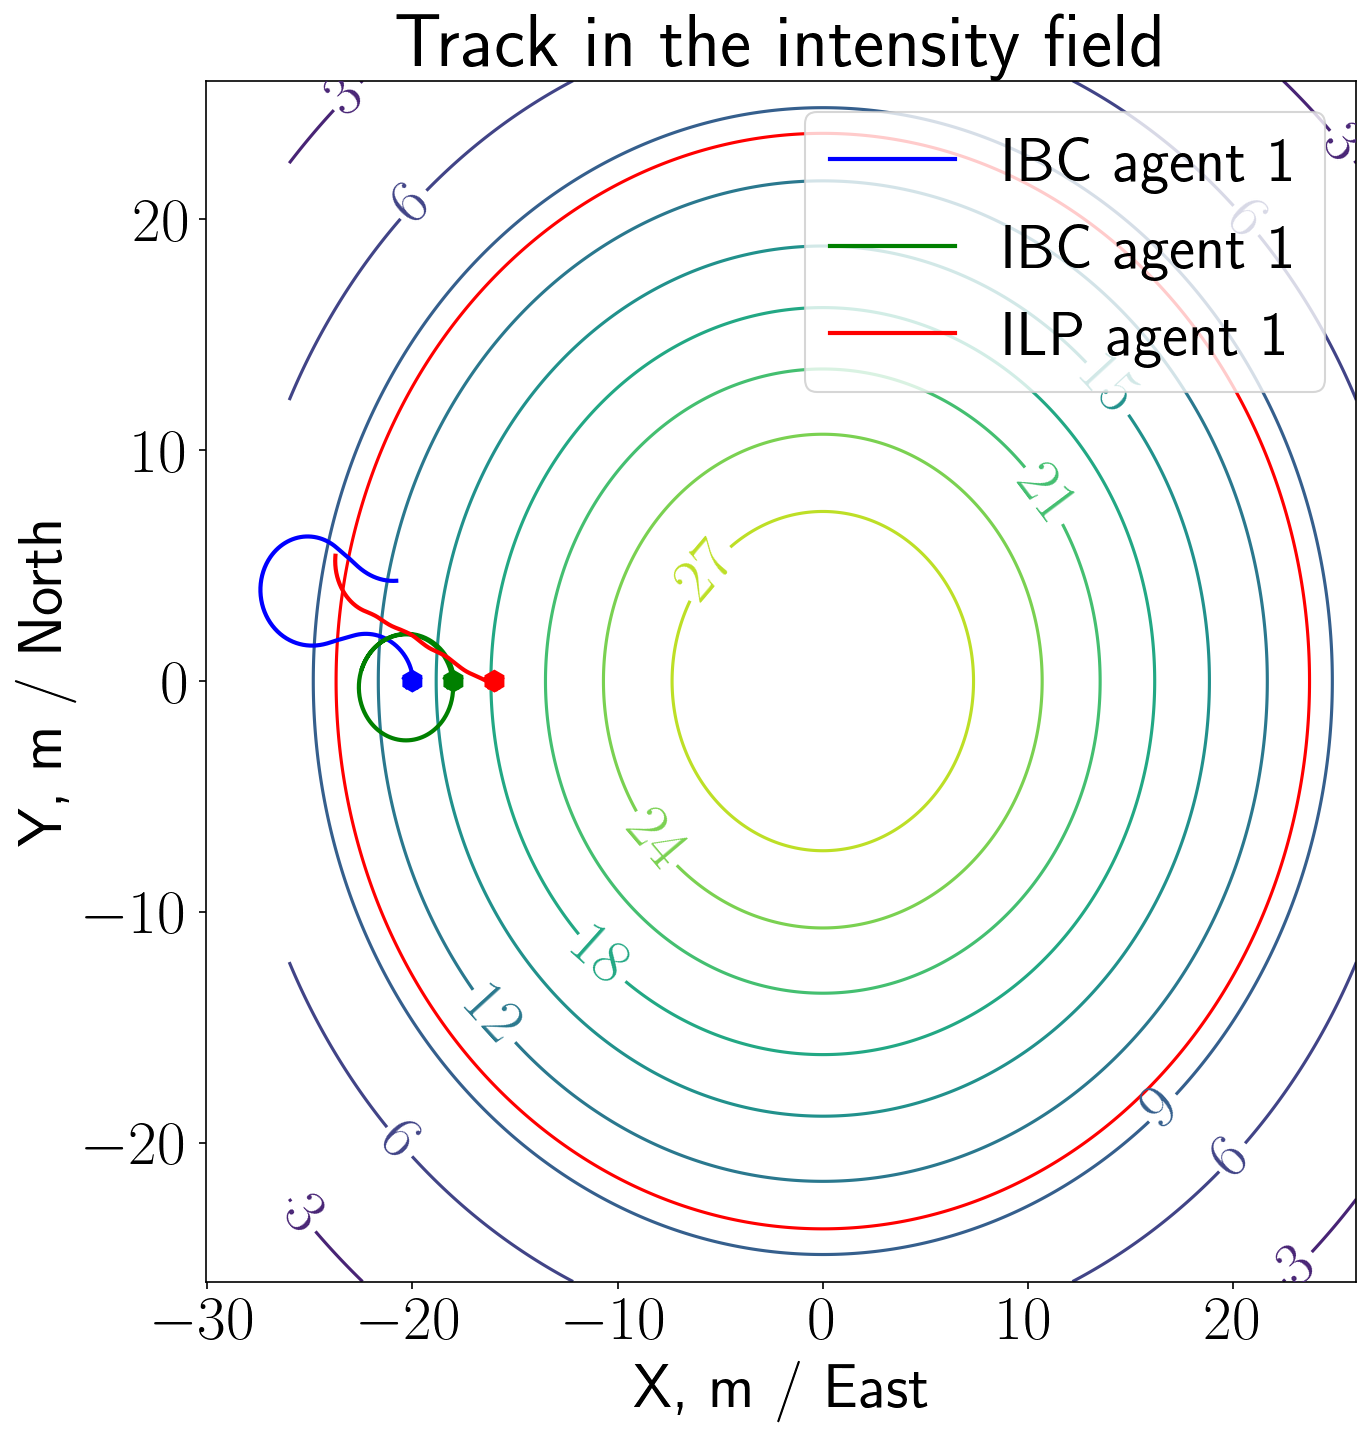

In [8]:
plotter.plotting_track(combine=True)

In [9]:
for idx, (controller, sim_data) in enumerate(controller_runs):
    label = controller_labels[idx]
    snapshot = controller.track_snapshot()
    datasets = prepare_animation_datasets(sim_data, snapshot)
    fps = snapshot.get('fps', arguments.FPS)
    animation_html = create_track_animation(controller, snapshot, datasets, fps)
    if animation_html is not None:
        display(HTML(f"<h3>{label}: анимация траектории</h3>"))
        display(animation_html)

for controller_index, (controller, _) in enumerate(controller_runs):
    for vehicle_index, error_sum in enumerate(controller.sum_error_values):
        print(f"Controller {controller_index + 1} vehicle {vehicle_index}: e_norm = {error_sum / controller.sim_time}")
    print(f"Controller {controller_index + 1} maximum error threshold: {controller.e_max}")


RuntimeError: latex was not able to process the following string:
b'\\u0430\\u0433\\u0435\\u043d\\u0442 1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmph06l6n3i b9350a58e0ea554136f4ae17bab00315.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./b9350a58e0ea554136f4ae17bab00315.tex
LaTeX2e <2024-06-01> patch level 2
L3 programming layer <2024-09-10>
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/02/08 v1.4n Standard LaTeX document class
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2024/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2024/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/t

RuntimeError: latex was not able to process the following string:
b'\\u0430\\u0433\\u0435\\u043d\\u0442 1'

Here is the full command invocation and its output:

latex -interaction=nonstopmode --halt-on-error --output-directory=tmpt6ky3of3 b9350a58e0ea554136f4ae17bab00315.tex

This is pdfTeX, Version 3.141592653-2.6-1.40.26 (TeX Live 2024) (preloaded format=latex)
 restricted \write18 enabled.
entering extended mode
(./b9350a58e0ea554136f4ae17bab00315.tex
LaTeX2e <2024-06-01> patch level 2
L3 programming layer <2024-09-10>
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/article.cls
Document Class: article 2024/02/08 v1.4n Standard LaTeX document class
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/size10.clo))
(/usr/local/texlive/2024/texmf-dist/tex/latex/type1cm/type1cm.sty)
(/usr/local/texlive/2024/texmf-dist/tex/latex/cm-super/type1ec.sty
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/t1cmr.fd))
(/usr/local/texlive/2024/texmf-dist/tex/latex/base/inputenc.sty)
(/usr/local/t

<Figure size 800x800 with 1 Axes>